# GeoBench WindTurbine

## Intro

The Wind Turbine dataset is designed for renewable energy infrastructure detection using high-resolution satellite imagery. The dataset provides precise annotations of wind turbines and wind farm installations across diverse geographical and environmental conditions, enabling automated detection and mapping of wind energy infrastructure for renewable energy planning, environmental impact assessment, and energy policy applications.

## GeoBenchV2 Processing Pipeline

### Preprocessing Steps

1. **High-Resolution Infrastructure Processing**:
   - Processed sub-meter resolution satellite imagery for detailed turbine analysis
   - Applied contrast enhancement for improved turbine visibility
   - Generated turbine-centered patches with consistent sizing

2. **Wind Turbine Annotation Processing**:
   - Converted expert annotations to standardized object detection format
   - Applied precision validation for turbine location accuracy
   - Maintained consistency across different turbine sizes and configurations

3. **Quality Control and Filtering**:
   - Filtered imagery with poor visibility or atmospheric interference
   - Applied infrastructure completeness checks for accurate representation
   - Maintained diversity across different wind farm layouts and turbine types

4. **Split Generation**:
   - Applied geographic clustering to prevent spatial data leakage
   - Used wind farm-based splitting for installation independence
   - Maintained diversity in wind energy infrastructure across splits

### Label Processing
- **Object Detection Format**: COCO-style bounding boxes for wind turbine detection
- **Multi-Scale Infrastructure**: Annotations covering various turbine sizes and installation types
- **Expert Validation**: Infrastructure annotations validated by renewable energy experts

In [1]:
import os
from pathlib import Path

import torch

from geobench_v2.datamodules import GeoBenchWindTurbineDataModule
from geobench_v2.datasets import GeoBenchWindTurbine
from geobench_v2.datasets.normalization import SatMAENormalizer, ZScoreNormalizer
from geobench_v2.datasets.visualization_util import (
    compare_normalization_methods,
    compute_batch_histograms,
    plot_batch_histograms,
    plot_channel_histograms,
)

%load_ext autoreload
%autoreload 2

In [2]:
DATA_ROOT = Path("../../data/wind_turbine")

STATS_SATMAE_PATH = os.path.join(DATA_ROOT, "wind_turbine_stats_satmae.json")
STATS_CLIP_RESCALE_PATH = os.path.join(
    DATA_ROOT, "wind_turbine_stats_clip_rescale.json"
)

In [3]:
band_order = GeoBenchWindTurbine.band_default_order

datamodule = GeoBenchWindTurbineDataModule(
    img_size=256,
    batch_size=4,
    num_workers=4,
    root=DATA_ROOT,
    band_order=band_order,
    data_normalizer=torch.nn.Identity(),  # we do custom normalization in the tutorial
)
datamodule.setup("fit")

Using provided pre-initialized normalizer instance: Identity
Using provided pre-initialized normalizer instance: Identity


## Dataset Statistics

Computed over the training dataset.

### Image Statistics

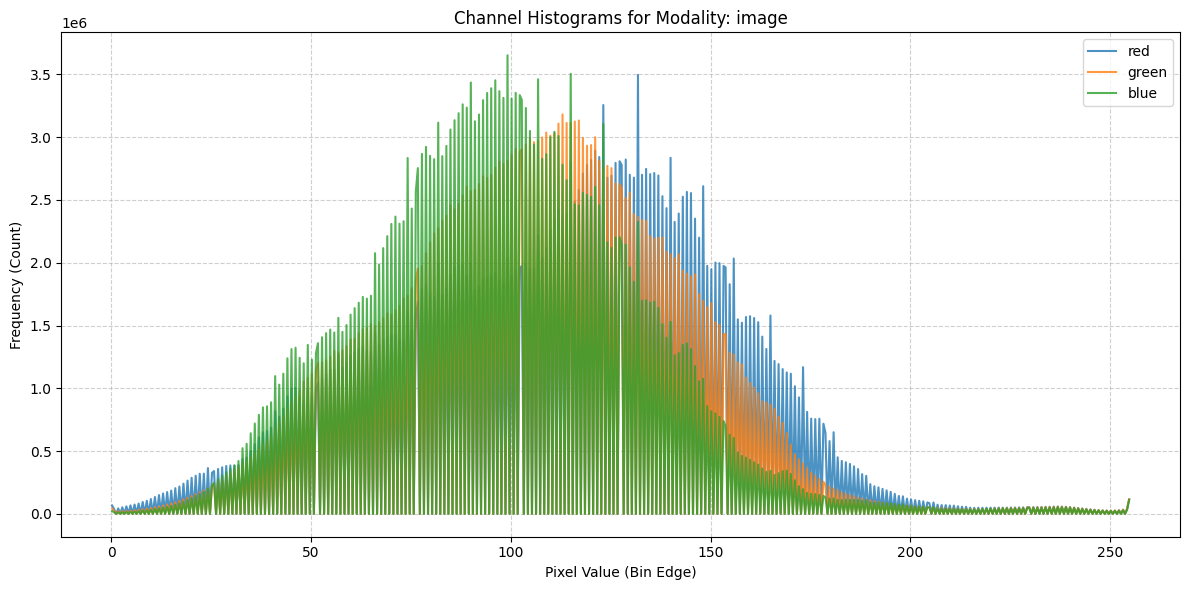

In [4]:
fig = plot_channel_histograms(STATS_SATMAE_PATH)

### Target Statistics

In [5]:
# fig = visualize_object_detection_target_statistics(STATS_SATMAE_PATH, "Wind Turbine")

### Raw Batch Statistics

[<Figure size 1200x500 with 1 Axes>]

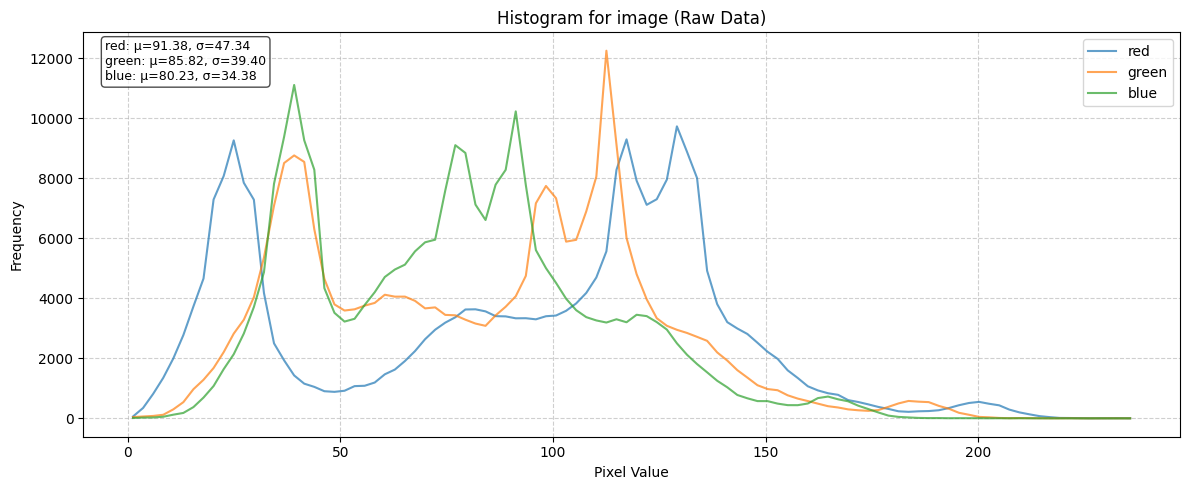

In [6]:
# Get a batch of data from the dataloader
train_dataloader = datamodule.train_dataloader()
raw_batch = next(iter(train_dataloader))

raw_batch_stats = compute_batch_histograms(raw_batch, n_bins=100)


raw_figs = plot_batch_histograms(
    raw_batch_stats, band_order, title_suffix=" (Raw Data)"
)
raw_figs

### Effect of different Normalization Schemes

In [7]:
zscore_normalizer = ZScoreNormalizer(STATS_CLIP_RESCALE_PATH, band_order)
satmae_normalizer = SatMAENormalizer(STATS_SATMAE_PATH, band_order)

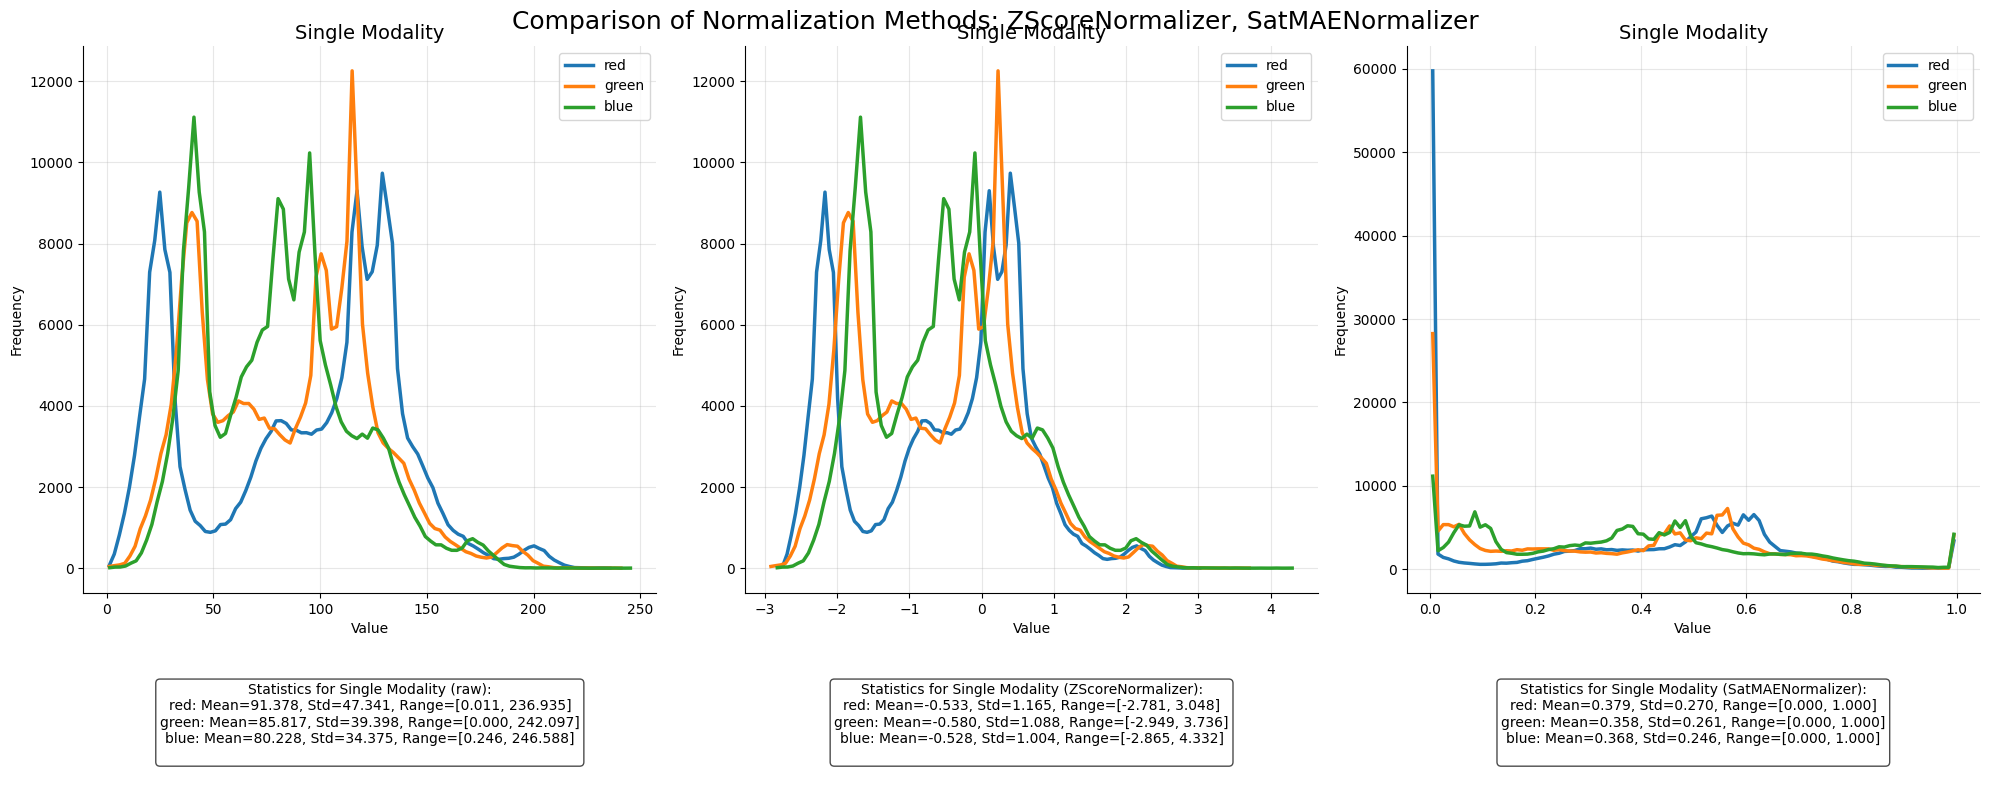

In [8]:
norm_fig, normalized_batches = compare_normalization_methods(
    raw_batch, [zscore_normalizer, satmae_normalizer], datamodule
)

## Visualize Batch Data

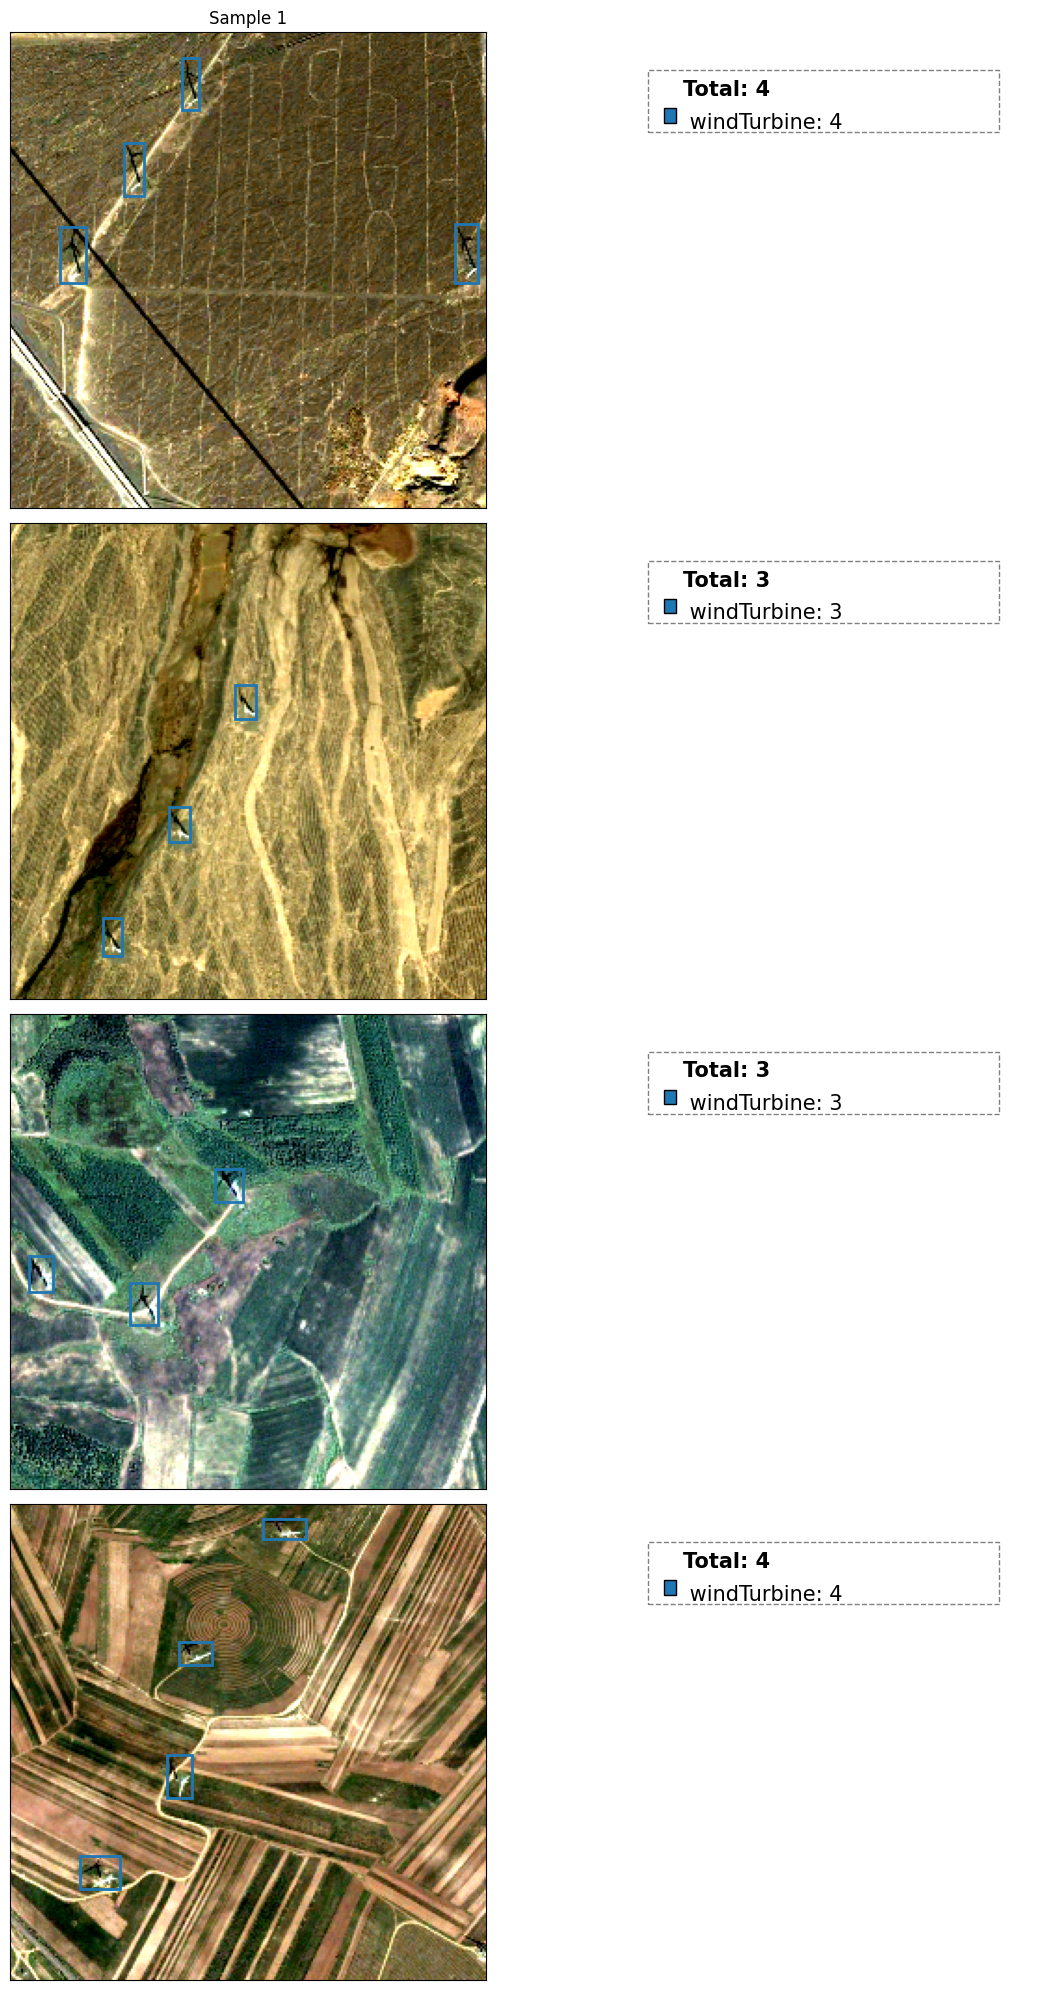

In [9]:
fig, batch = datamodule.visualize_batch()